# Regressão Linear com PyTorch - Dataset Salary Data

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [ ]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [ ]:
#!/bin/bash
!curl -L -o /content/housesalesprediction.zip https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  779k  100  779k    0     0  2233k      0 --:--:-- --:--:-- --:--:-- 2233k


In [ ]:
!unzip /content/housesalesprediction.zip

Archive:  /content/housesalesprediction.zip
  inflating: kc_house_data.csv       


In [ ]:

df = pd.read_csv('/content/kc_house_data.csv')


In [ ]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
df = df.drop(['id', 'date'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode        21613 non-null  int64  
 15  lat            21613 non-null  float64
 16  long           21613 non-null  float64
 17  sqft_living15  21613 non-null  int64  
 18  sqft_l

In [ ]:
y = df['price'].values.reshape(-1,1)

In [ ]:
y.shape

(21613, 1)

In [ ]:
y

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

In [ ]:
y = df['price'].values.reshape(-1,1)

In [ ]:
y

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

In [ ]:
x= df.drop(['price'], axis=1).values

In [ ]:
x

array([[ 3.00000e+00,  1.00000e+00,  1.18000e+03, ..., -1.22257e+02,
         1.34000e+03,  5.65000e+03],
       [ 3.00000e+00,  2.25000e+00,  2.57000e+03, ..., -1.22319e+02,
         1.69000e+03,  7.63900e+03],
       [ 2.00000e+00,  1.00000e+00,  7.70000e+02, ..., -1.22233e+02,
         2.72000e+03,  8.06200e+03],
       ...,
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ..., -1.22299e+02,
         1.02000e+03,  2.00700e+03],
       [ 3.00000e+00,  2.50000e+00,  1.60000e+03, ..., -1.22069e+02,
         1.41000e+03,  1.28700e+03],
       [ 2.00000e+00,  7.50000e-01,  1.02000e+03, ..., -1.22299e+02,
         1.02000e+03,  1.35700e+03]])

### Normalização dos dados

In [ ]:

x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(x)


y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 18])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 18])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [ ]:
x.shape[1]

18

In [ ]:
model = torch.nn.Linear(18, 1)

### Verificando a inicialização dos parâmetros

In [ ]:
model.weight.data

tensor([[-0.1471,  0.0082,  0.1343, -0.1691, -0.0890,  0.0986, -0.1520, -0.0262,
         -0.1777,  0.2186,  0.1271, -0.2179, -0.1301,  0.0836,  0.0129,  0.0625,
         -0.1928, -0.1262]])

### Testando o predict da rede

In [ ]:
model(torch.ones(5, 18))

tensor([[-0.5756],
        [-0.5756],
        [-0.5756],
        [-0.5756],
        [-0.5756]], grad_fn=<AddmmBackward0>)

In [ ]:
model(X_train_tensor[:3])

tensor([[-0.4149],
        [ 0.9690],
        [-0.1848]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
num_epochs = 400

### Laço de treinamento

In [ ]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)


    loss.backward()
    optimizer.step()

    return loss.item()

In [ ]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval()
    with torch.no_grad():
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item()

In [ ]:

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)


    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/400], Train Loss: 1.272266, Val Loss: 1.221789
Epoch[4/400], Train Loss: 0.999806, Val Loss: 0.986075
Epoch[6/400], Train Loss: 0.817429, Val Loss: 0.826761
Epoch[8/400], Train Loss: 0.693946, Val Loss: 0.717646
Epoch[10/400], Train Loss: 0.609129, Val Loss: 0.641686
Epoch[12/400], Train Loss: 0.549838, Val Loss: 0.587767
Epoch[14/400], Train Loss: 0.507518, Val Loss: 0.548623
Epoch[16/400], Train Loss: 0.476583, Val Loss: 0.519489
Epoch[18/400], Train Loss: 0.453374, Val Loss: 0.497223
Epoch[20/400], Train Loss: 0.435481, Val Loss: 0.479742
Epoch[22/400], Train Loss: 0.421308, Val Loss: 0.465657
Epoch[24/400], Train Loss: 0.409790, Val Loss: 0.454032
Epoch[26/400], Train Loss: 0.400209, Val Loss: 0.444229
Epoch[28/400], Train Loss: 0.392074, Val Loss: 0.435808
Epoch[30/400], Train Loss: 0.385047, Val Loss: 0.428461
Epoch[32/400], Train Loss: 0.378888, Val Loss: 0.421967
Epoch[34/400], Train Loss: 0.373427, Val Loss: 0.416168
Epoch[36/400], Train Loss: 0.368538, Val Loss: 0.410

## Avaliação

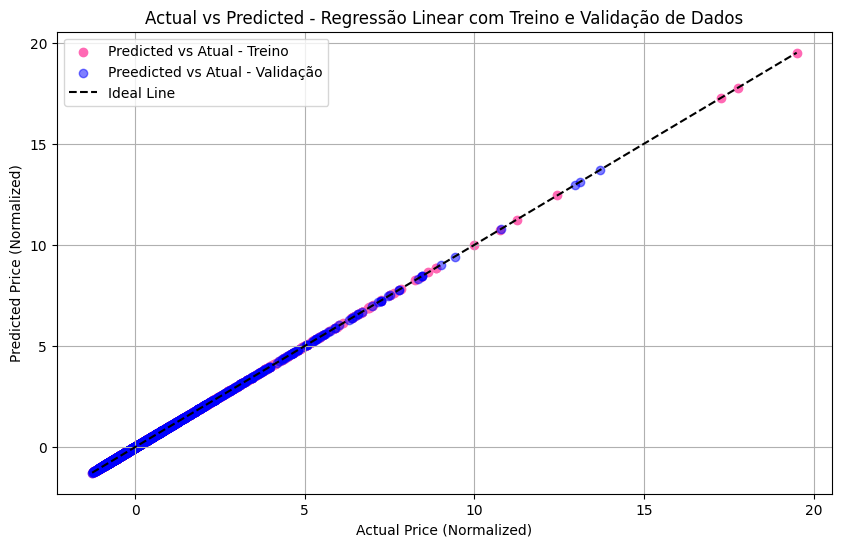

In [ ]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot original training data
plt.scatter(y_train_tensor.numpy(), y_train_tensor.numpy(), label='Predicted vs Atual - Treino', color ='hotpink')

# Plot original validation data
plt.scatter(y_val_tensor.numpy(), y_val_tensor.numpy(), alpha=0.5, label='Preedicted vs Atual - Validação', color = 'blue')

max_val = max (y_train_tensor.max(), y_val_tensor.max()).item()
min_val = min (y_train_tensor.min(), y_val_tensor.min()).item()
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Line')


# Plot fitting line for training data
#plt.plot(X_train_tensor.numpy(), y_pred_train.data.numpy(), 'k-', label='Fitting Line (Train)')

# Plot fitting line for validation data
#plt.plot(X_val_tensor.numpy(), y_pred_val.data.numpy(), 'b--', label='Fitting Line (Validation)')

plt.xlabel('Actual Price (Normalized)')
plt.ylabel( 'Predicted Price (Normalized)')
plt.title('Actual vs Predicted - Regressão Linear com Treino e Validação de Dados')
plt.legend()
plt.grid(True)
plt.show()

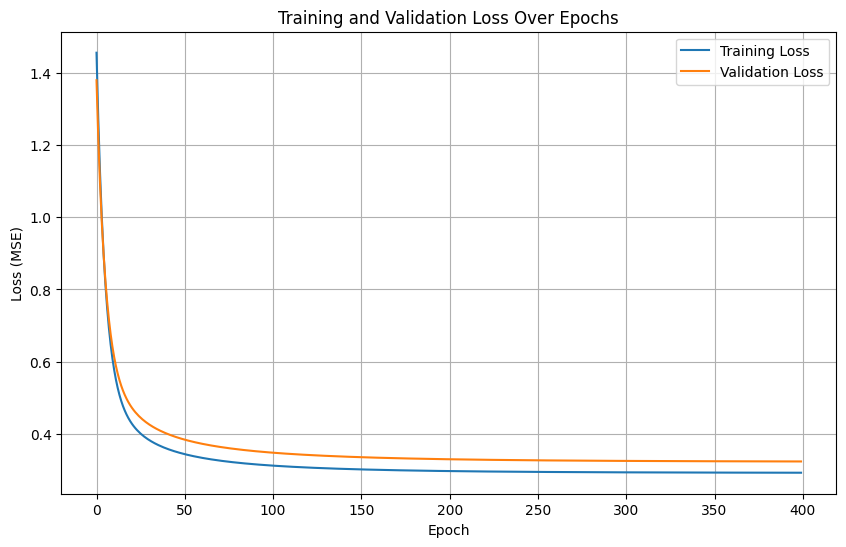

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()